In [ ]:
import pandas as pd
from scipy.optimize import minimize
import numpy as np
from tqdm import tqdm, trange
from joblib import Parallel, delayed

In [ ]:
df = pd.read_excel('HW3_dataset.xlsx')

In [ ]:
assets = ['Equity', 'Bonds', 'Credits', 'Comm', 'HY']
features = ['US_Earnings_yield', 'US_DIV_Yield', 'Equity Volatility', 'TED', 'Credit Subindex',
           'Leverage Subindex', 'Risk Subindex', 'Non Financial Leverage Subindex', 'Credit Spread',
           'Inflation', 'IP YoY', 'yields 10Y', 'Term Spread', 'CAPE']
n_features = round((len(features)) ** 0.5)  # number of features to use to train single tree
df = df.rename(columns={'Unnamed: 0': 'Date'})

In [ ]:
df_assets = df[assets]
df_features = df[['Date', 'RF'] + features]

Так как нам надо предсказывать будущую прибыль, то сдвинем все доходности наших активов на 1 вперед:

In [ ]:
df_assets_shifted = df_assets.shift(-1)
df_final = pd.concat([df_features, df_assets_shifted], axis=1)
df_final = df_final.iloc[:-1]
df_final = df_final.set_index('Date')

In [ ]:
df_train = df_final.loc[:'2004-09-30']
df_test = df_final.loc['2004-10-31':]

train_data = df_train.to_numpy()
test_data = df_test.to_numpy()

In [ ]:
def calc_SR(assets_data, rf, w_prev = None, t_lambda = 0):  # оптимизация коэфф-а шарпа без turnover, для обучения
    expected_returns = np.mean(assets_data, axis=0)
    cov_matrix = np.cov(assets_data.T)

    ew_returns = assets_data @ (np.ones(5) / 5)
    target_vol = np.std(ew_returns)

    init_weights = np.ones(5) / 5
    bounds = [(0.0, 1.0) for _ in range(5)]

    sum_constraint = {
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1.0
    }
    volatility_constraint = {
        'type': 'eq',
        'fun': lambda w: np.sqrt(w @ cov_matrix @ w) - target_vol
    }
    constraints = [sum_constraint, volatility_constraint]

    def objective(w):
        portfolio_return = w @ expected_returns
        return -(portfolio_return - rf)

    def objective_t(w):
        portfolio_return = w @ expected_returns
        t_cost = t_lambda * np.sum(np.abs(w - w_prev))
        return -(portfolio_return - rf - t_cost)
    if w_prev is None:
        result = minimize(
            objective,
            init_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9, 'disp': False}
        )
    else:
        result = minimize(
            objective_t,
            init_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9, 'disp': False}
        )


    optimal_weights = result.x
    optimal_weights = np.maximum(optimal_weights, 0)  # на всякий случай
    optimal_weights = optimal_weights / np.sum(optimal_weights)  # береженого Бог бережет
    portfolio_vol = np.sqrt(optimal_weights @ cov_matrix @ optimal_weights)
    portfolio_return = optimal_weights @ expected_returns
    t_cost = t_lambda * np.sum(np.abs(optimal_weights - w_prev)) if (w_prev is not None) else 0
    sharpe_ratio = (portfolio_return - rf - t_cost) / portfolio_vol
    return {
        'weights': optimal_weights,
        'sharpe': sharpe_ratio,
        'return': portfolio_return,
        'expected_returns': expected_returns,
        'cov_matrix': cov_matrix,
        'target_vol': target_vol
    }

In [ ]:
def opt_weights(expected_returns, cov_matrix, rf, target_vol, w_prev = None, t_lambda = 0):  # оптимизация SR с turnover для inference
    init_weights = np.ones(5) / 5
    bounds = [(0.0, 1.0) for _ in range(5)]

    sum_constraint = {
        'type': 'eq',
        'fun': lambda w: np.sum(w) - 1.0
    }
    volatility_constraint = {
        'type': 'eq',
        'fun': lambda w: np.sqrt(w @ cov_matrix @ w) - target_vol
    }
    constraints = [sum_constraint, volatility_constraint]

    def objective(w):
        portfolio_return = w @ expected_returns
        return -(portfolio_return - rf)

    def objective_t(w):
        portfolio_return = w @ expected_returns
        t_cost = t_lambda * np.sum(np.abs(w - w_prev))
        return -(portfolio_return - rf - t_cost)
    if w_prev is None:
        result = minimize(
            objective,
            init_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9, 'disp': False}
        )
    else:
        result = minimize(
            objective_t,
            init_weights,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 1000, 'ftol': 1e-9, 'disp': False}
        )


    optimal_weights = result.x
    optimal_weights = np.maximum(optimal_weights, 0)  # на всякий случай
    optimal_weights = optimal_weights / np.sum(optimal_weights)  # береженого Бог бережет
    return optimal_weights

In [ ]:
class TreeNode:
    def __init__(self, depth=0):
        self.depth = depth
        self.feature_index = None
        self.threshold = None
        self.left = None
        self.right = None
        self.is_leaf = False
        self.indxs = None
        self.leaf_data = None

class TreeRegressor():
    def __init__(self, features):
        self.features = np.array(features, dtype=int)  # индексы признаков будут заложены в самом TreeClassifier.
        self.min_obs = 36
        self.max_depth = 3
        self.n_assets = 5
        self.root = None
        self.X = None  # признаки
        self.Y = None  # доходности активов
        self.rf_arr = None
        self.t_lambda = 0.002


    def node_sr(self, idx, rf):
        if len(idx) < self.min_obs:  # ограничение на число наблюдений в листе
            return -np.inf, None
        res = calc_SR(self.Y[idx], rf)
        return (float(res['sharpe']), res)

    def split_score(self, left_idx, right_idx):
        nL, nR = len(left_idx), len(right_idx)

        rf_l = np.mean(self.rf_arr[left_idx])
        rf_r = np.mean(self.rf_arr[right_idx])
        sharpe_L = self.node_sr(left_idx, rf_l)[0]
        sharpe_R = self.node_sr(right_idx, rf_r)[0]

        return (nL * sharpe_L + nR * sharpe_R) / (nL + nR)

    def fit(self, X, Y, rf_arr):
        self.X = np.asarray(X)
        self.Y = np.asarray(Y)
        self.rf_arr = np.asarray(rf_arr)

        dataset_len = self.X.shape[0]
        idxs = np.arange(dataset_len)
        self.root = self.build_tree(idxs, depth=0)

    def make_leaf(self, node, indxs):
        node.is_leaf = True
        node.indxs = np.asarray(indxs)
        rf_leaf = float(np.mean(self.rf_arr[indxs]))
        node.leaf_data = self.node_sr(indxs, rf_leaf)[1]
        return node

    def build_tree(self, idxs, depth):
        node = TreeNode(depth=depth)

        if depth >= self.max_depth or len(idxs) <= 2 * self.min_obs:  # если нет шанса разделить, то создаем лист
            return self.make_leaf(node, idxs)

        best_sc = -np.inf
        best_feat, best_thr = None, None
        best_left_spl, best_right_spl = None, None

        for feat in self.features:
            x_values = self.X[idxs, feat]

            order = np.argsort(x_values)
            sorted_idxs = idxs[order]
            x_sorted = x_values[order]

            for i in range(self.min_obs,
                                   len(sorted_idxs) - self.min_obs + 1):

                # если есть одинаковые значение, то нужно обработать только одно из них, иначе будет неправильное разбиение
                if x_sorted[i] == x_sorted[i - 1]:
                    continue

                thr = 0.5 * (x_sorted[i] + x_sorted[i - 1])
                left_idx = sorted_idxs[:i]
                right_idx = sorted_idxs[i:]
                score = self.split_score(left_idx, right_idx)
                if score > best_sc:
                    best_sc = score
                    best_feat = feat
                    best_thr = thr
                    best_left_spl = left_idx
                    best_right_spl = right_idx

        if best_feat is None:
            return self.make_leaf(node, idxs)

        node.feature_index = best_feat
        node.threshold = best_thr
        node.left = self.build_tree(best_left_spl, depth + 1)  # рекурсивно строим дерево
        node.right = self.build_tree(best_right_spl, depth + 1)

        return node

    def search_leaf(self, x, node):
        if node.is_leaf or node.feature_index is None:
            return node
        if x[node.feature_index] <= node.threshold:
            return self.search_leaf(x, node.left)
        return self.search_leaf(x, node.right)

    def predict(self, x, rf, w_prev = None):
        x = np.asarray(x)

        leaf = self.search_leaf(x, self.root)
        exp_ret, cov_m, target_vol = leaf.leaf_data['expected_returns'], leaf.leaf_data['cov_matrix'], leaf.leaf_data['target_vol']

        return opt_weights(exp_ret, cov_m, rf, target_vol, w_prev, self.t_lambda)


In [ ]:
X_train = df_train[features].to_numpy()
Y_train = df_train[assets].to_numpy()
rf_train = df_train['RF'].to_numpy().astype(float)

X_test  = df_test[features].to_numpy()
Y_test  = df_test[assets].to_numpy()
rf_test = df_test['RF'].to_numpy().astype(float)

In [ ]:
def fit_one_tree(i, X_full, Y_full, rf_full, n_samples, n_total_features, n_features):
    feat_idx = np.random.choice(n_total_features, size=n_features, replace=False)

    boot_idx = np.random.choice(n_samples, size=n_samples, replace=True)

    X_boot = X_full[boot_idx][:, feat_idx]
    Y_boot = Y_full[boot_idx]
    rf_boot = rf_full[boot_idx]

    tree = TreeRegressor(features=np.arange(n_features))  # я решил фильтровать датасет на признаки
    # заранее, чтобы не копировать все данные полностью лишний раз

    tree.fit(X_boot, Y_boot, rf_boot)

    return tree, feat_idx

class BaggingRandomForest:
    def __init__(self, n_trees=200, n_features=None):

        self.n_trees = n_trees
        self.n_features = n_features

        self.trees = []
        self.features_subsets = []

    def fit(self, X_full, Y_full, rf_full):

        self.trees = []
        self.features_subsets = []
        n_samples, n_total_features = X_full.shape

        results = Parallel(n_jobs=14, prefer="processes")(
            delayed(fit_one_tree)(
                i, X_full, Y_full, rf_full,
                n_samples, n_total_features, self.n_features
            )
            for i in range(self.n_trees)
        )
        self.trees = [tree for tree, _ in results]
        self.features_subsets = [feat_idx for _, feat_idx in results]


    def predict(self, X_test, Y_test, rf_test):

        T = X_test.shape[0]

        W = np.zeros((T, 5))
        w_prev = None

        for t in trange(T):
            x_t_full = X_test[t]
            rf_t = float(rf_test[t])

            w_trees = np.zeros((self.n_trees, 5))

            for k, (tree, feat_idx) in enumerate(zip(self.trees, self.features_subsets)):
                x_cur = x_t_full[feat_idx]
                w_k = tree.predict(x_cur, rf_t, w_prev)
                w_trees[k] = w_k

            w_avg = w_trees.mean(axis=0)
            W[t] = w_avg

            r_t = Y_test[t]
            w_next_period = w_avg * (1.0 + r_t)
            w_next_period = w_next_period / w_next_period.sum()

            w_prev = w_next_period

        return W


In [ ]:
forest = BaggingRandomForest(n_trees=200, n_features=n_features)
forest.fit(X_train, Y_train, rf_train)

In [ ]:
W = forest.predict(X_test, Y_test, rf_test)

100%|██████████████████████████████████████████████████████████████████████████████| 219/219 [1:06:19<00:00, 18.17s/it]


In [ ]:
n_assets = Y_test.shape[1]
w_ew = np.ones(5) / 5

ret_ew = Y_test @ w_ew
cum_ew = np.cumprod(1.0 + ret_ew)

In [ ]:
T = Y_test.shape[0]

ret_forest = np.zeros(T)

for t in range(T):
    ret_forest[t] = W[t] @ Y_test[t]
cum_forest = np.cumprod(1.0 + ret_forest)

In [ ]:
print("Final cumulative return EW:", cum_ew[-1])
print("Final cumulative return Forest:", cum_forest[-1])

Final cumulative return EW: 2.286540544202028
Final cumulative return Forest: 2.4281929001762794


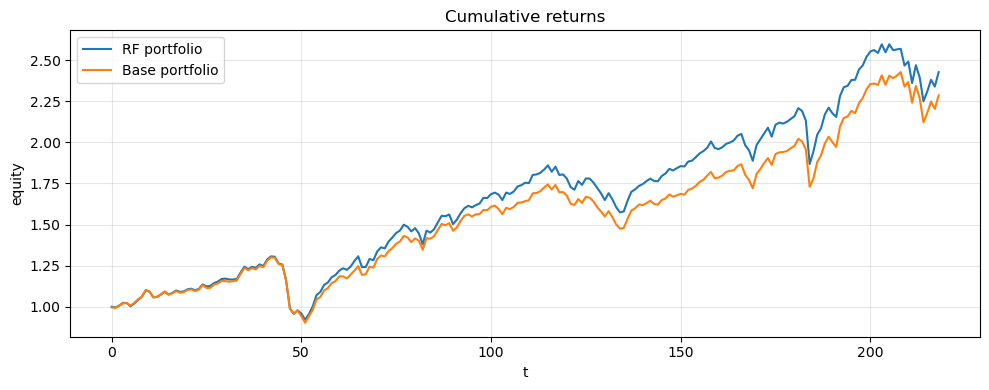

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(cum_forest, label="Random Forest portfolio")
plt.plot(cum_ew, label="Equal weight portfolio")
plt.title("Cumulative returns")
plt.xlabel("t")
plt.ylabel("equity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
np.save('brf_weights_2.npy', W)

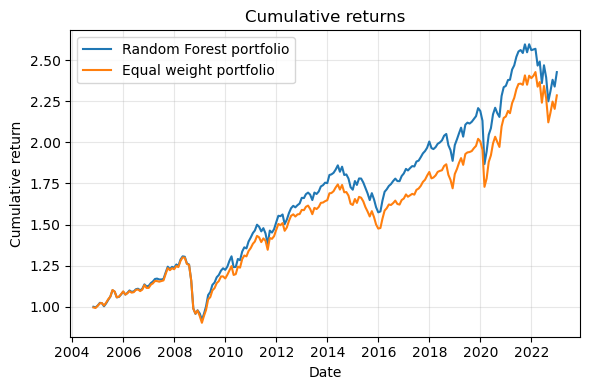

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(df_test.index, cum_forest, label="Random Forest portfolio")
plt.plot(df_test.index, cum_ew, label="Equal weight portfolio")
plt.title("Cumulative returns")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

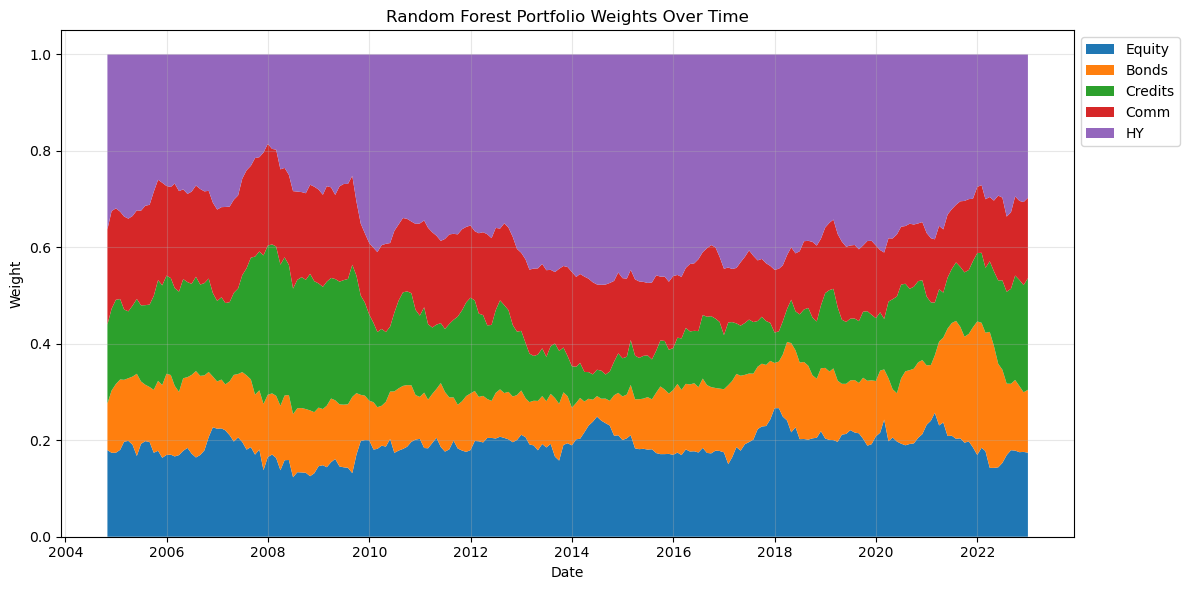

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(figsize=(12, 6))

# Stacked area plot
plt.stackplot(df_test.index, W.T, labels=[f'{assets[i]}' for i in range(5)])
plt.xlabel('Date')
plt.ylabel('Weight')
plt.title('Random Forest Portfolio Weights Over Time')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df_test

,RF,US_Earnings_yield,US_DIV_Yield,Equity Volatility,TED,Credit Subindex,Leverage Subindex,Risk Subindex,Non Financial Leverage Subindex,Credit Spread,Inflation,IP YoY,yields 10Y,Term Spread,CAPE,Equity,Bonds,Credits,Comm,HY
Date,,,,,,,,,,,,,,,,,,,,
2004-10-31,0.0011,0.0517,0.0171,0.094587,-0.04,-0.26910,-0.10833,-0.74099,0.63958,0.01380,0.025392,0.025813,0.043677,0.030477,25.668407,0.0469,-0.025045,-0.010396,-0.048373,0.012057
2004-11-30,0.0015,0.0519,0.0172,0.122635,0.00,-0.28987,0.00268,-0.74500,0.69631,0.01360,0.031909,0.033515,0.042757,0.029557,25.411656,0.0359,0.019908,0.014177,-0.099886,0.014908
2004-12-31,0.0016,0.0499,0.0166,0.100658,-0.14,-0.30019,0.02891,-0.75604,0.74158,0.01310,0.036216,0.029020,0.045674,0.027674,26.465311,-0.0260,0.017247,0.008090,0.067615,-0.001300
2005-01-31,0.0016,0.0488,0.0162,0.092499,-0.03,-0.28921,-0.01188,-0.73501,0.79996,0.01270,0.033423,0.036566,0.044070,0.024870,27.144809,0.0205,-0.016298,-0.006436,0.062261,0.014708
2005-02-28,0.0016,0.0500,0.0167,0.109415,-0.05,-0.28468,-0.01054,-0.75022,0.85065,0.01250,0.028449,0.038516,0.042716,0.023516,26.587251,-0.0176,-0.009112,-0.010770,0.075593,-0.029079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-31,0.0019,0.0506,0.0164,0.213554,-0.58,0.16828,0.43242,-0.28661,-0.93167,0.01985,0.084132,0.030060,0.027069,0.017469,29.004618,-0.0916,-0.062641,-0.053082,-0.078012,-0.039716
2022-09-30,0.0019,0.0500,0.0154,0.200041,-0.30,0.15682,0.36311,-0.26580,-0.86215,0.01910,0.082274,0.031050,0.031975,0.009175,30.698763,0.0806,-0.027233,-0.011146,0.067049,0.025985
2022-10-31,0.0023,0.0552,0.0170,0.250597,-0.55,0.23531,0.32008,-0.12238,-0.78475,0.02000,0.082149,0.045092,0.038767,0.015967,28.229885,0.0489,0.055480,0.049174,-0.017055,0.021704


In [ ]:
stat_df = pd.DataFrame({'Strategy':['Random Forest', 'Equal Weight'], 'Mean ret. %': [round(100*np.mean(ret_forest),3), round(100*np.mean(ret_ew),3)],
                       'Max Monthly ret': [np.round(100*np.max(ret_forest),2), np.round(100*np.max(ret_ew),2)],
                        'Min Monthly ret': [np.round(100*np.min(ret_forest),2), np.round(100*np.min(ret_ew),2)],
                        'Annual Volat.' : [round(np.std(ret_forest)*np.sqrt(12),4), round(np.std(ret_ew)*np.sqrt(12),4)],
                        'Total return': [round(cum_forest[-1],3), round(cum_ew[-1],3)]
                       })

In [ ]:
stat_df

,Strategy,Mean ret. %,Max Monthly ret,Min Monthly ret,Annual Volat.,Total return
0,Random Forest,0.440,6.92,-14.61,0.0887,2.428
1,Equal Weight,0.411,6.53,-14.81,0.0867,2.287


In [ ]:
latex_code = stat_df.to_latex(index=False)
print(latex_code)

\begin{tabular}{lrrrrr}
\toprule
Strategy & Mean ret. % & Max Monthly ret & Min Monthly ret & Annual Volat. & Total return \\
\midrule
Random Forest & 0.440000 & 6.920000 & -14.610000 & 0.088700 & 2.428000 \\
Equal Weight & 0.410000 & 6.530000 & -14.810000 & 0.086700 & 2.287000 \\
\bottomrule
\end{tabular}



In [ ]:
from scipy import stats
block = 250

means_ew = []
means_forest = []
pvals = []
dates = []

for a in range(0, len(ret_ew), block):
    b = min(a + block, len(ret_ew))

    x = 100 * ret_forest[a:b]
    y = 100 * ret_ew[a:b]
    means_forest.append(np.mean(x))
    means_ew.append(np.mean(y))
    pvals.append(stats.ttest_rel(x, y).pvalue)
    dates.append(f'{df_test.index[a].date()}-{df_test.index[b - 1].date()}')

df = pd.DataFrame({
    "Dates" : dates,
    "mean_forest_%": means_forest,
    "mean_ew_%": means_ew,
    "p_value": pvals
})


In [ ]:
df

,Dates,mean_forest_%,mean_ew_%,p_value
0,2004-10-31-2022-12-31,0.439604,0.410538,0.214667


In [ ]:
latex = df.to_latex(
    index=False,
    float_format="%.4f",
    caption="24-month block statistics (annualized volatility)",
    label="tab:24m_block_stats",
    column_format="cccccccccccc"
)

In [ ]:
print(latex)

\begin{table}
\caption{24-month block statistics (annualized volatility)}
\label{tab:24m_block_stats}
\begin{tabular}{cccccccccccc}
\toprule
Dates & mean_forest_% & mean_ew_% & p_value \\
\midrule
2004-10-31-2006-09-30 & 0.4404 & 0.4216 & 0.6329 \\
2006-10-31-2008-09-30 & -0.3991 & -0.3889 & 0.7927 \\
2008-10-31-2010-09-30 & 1.3786 & 1.2295 & 0.1741 \\
2010-10-31-2012-09-30 & 0.7149 & 0.7168 & 0.9833 \\
2012-10-31-2014-09-30 & 0.5012 & 0.3915 & 0.0520 \\
2014-10-31-2016-09-30 & -0.0740 & -0.1639 & 0.2123 \\
2016-10-31-2018-09-30 & 0.4944 & 0.4405 & 0.3342 \\
2018-10-31-2020-09-30 & 0.4131 & 0.4340 & 0.7893 \\
2020-10-31-2022-09-30 & 0.3292 & 0.4599 & 0.0923 \\
2022-10-31-2022-12-31 & 1.7013 & 1.6406 & 0.5835 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
df_test['RF'].mean()

0.0009748858447488583

In [ ]:
df_test['RF'].sample(10)

Date
2005-05-31    0.0024
2013-12-31    0.0000
2015-08-31    0.0000
2016-07-31    0.0002
2020-09-30    0.0001
2014-12-31    0.0000
2006-12-31    0.0040
2019-12-31    0.0014
2012-09-30    0.0001
2019-05-31    0.0021
Name: RF, dtype: float64